<h1>Project 1: Image Compression using DCT and DFT</h1>
<p>In this project well implement two different image compression techniques which are Discrete Cosine Transform and Discrete Fourier Transform. We'll compare how each one perfoms and how this relates to their mathematics.</p>

<h3>first we start with image preprocessing</h3> 

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.fftpack import dct, idct, fft, ifft
from skimage.util import img_as_float
from skimage.color import rgb2gray
import cv2

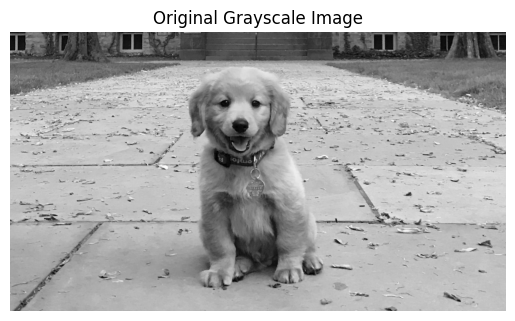

In [21]:
#image loading
image = cv2.imread('/Users/mohamedghaith/Documents/Uni/Year 5/DSP/Project/image-compression-dct-dft/dog.jpg')
# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = img_as_float(image)
gray_image = rgb2gray(image)
plt.imshow(gray_image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()

In [22]:
#i'll resize it to 256x256 for simplicity
image_resized = cv2.resize(gray_image,(256,256))

<h3> Now let's Divide the image into 8x8 blocks </h3>

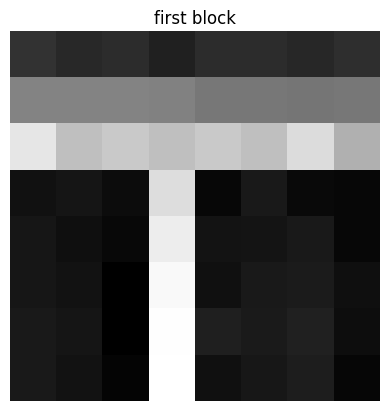

In [23]:
blksize =8
blocks = []
for i in range(0, image_resized.shape[0], blksize):
    for j in range(0, image_resized.shape[1], blksize):
        block = image_resized[i:i+blksize, j:j+blksize]
        blocks.append(block)
blocks = np.array(blocks)
plt.imshow(blocks[0], cmap='gray')
plt.title('first block')
plt.axis('off')
plt.show()

### Next we apply DCT to each block...but let's first understannd what and how DCT works:
<p>Given a signal x[n], we could previously use DFT to transform it to frequency domain where x[f] = summation of X[m] * e^(-j2pikn/N) over k=0 to N-1 and to get back to time representaion -> IDFT is then x[n] = summation of X[k]/N * e^(j2pikn/N) over k=0 to N-1. Obviously this yeilds complex numbers/sinusiods which are not ideal, nor cost effective, for image processing. It won't matter a lot when working on LTI systems, but for compression tasks, we want to avoid complex numbers as much as possible. Loss of information happens when we quantize the coefficients, and working with complex numbers makes this loss worse.
On the other hand, with DCT, the signal is represented as a sum of cosine functions oscillating at different frequencies, so losing a part of signal is less effective as another half represents the same information.
DCT is a similar transform that uses yields real numbers and cosines instead of complex exponentials. In DCT, large amount of signal information is cocentrated mostly in lower frequencies, which makes it more suitable for compression tasks as we can lose parts of the higher frequency components with less quality loss.(As we learned in information thery, higher freqs represent less important and the more probability of occurance, the less information they carry).</p>

In [24]:
#number of blocks
blocks

array([[[0.11942357, 0.09649159, 0.10940963, ..., 0.10660188,
         0.09439648, 0.1115875 ],
        [0.29624239, 0.29817254, 0.29720069, ..., 0.27003222,
         0.26441973, 0.26829052],
        [0.51119687, 0.42570362, 0.44732324, ..., 0.4247845 ,
         0.48798648, 0.39222103],
        ...,
        [0.05738051, 0.04939951, 0.01028154, ..., 0.064856  ,
         0.06946382, 0.04220961],
        [0.06392157, 0.05667586, 0.00945208, ..., 0.06791973,
         0.08321206, 0.03949338],
        [0.06500375, 0.04917961, 0.01878346, ..., 0.06152274,
         0.07329892, 0.02331955]],

       [[0.45264738, 0.50246078, 0.44372917, ..., 0.48709225,
         0.48905304, 0.45953032],
        [0.45253074, 0.48562561, 0.51996998, ..., 0.49050831,
         0.49219336, 0.44394178],
        [0.42572046, 0.4449087 , 0.46205025, ..., 0.48566762,
         0.45705243, 0.47325294],
        ...,
        [0.44957078, 0.42269275, 0.43897645, ..., 0.49956468,
         0.50046848, 0.47672461],
        [0.5

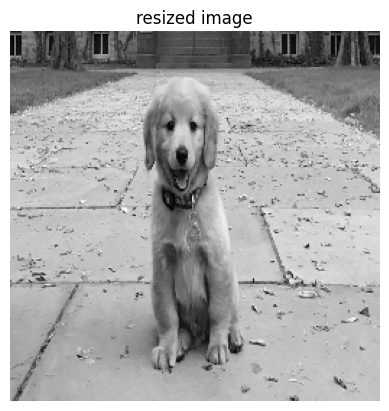

True

In [25]:
#plot resized image
plt.imshow(image_resized, cmap='gray')
plt.title('resized image')
plt.axis('off')
plt.show()
#i'll save the image for later comparison
cv2.imwrite('resized_image.png', (image_resized * 255).astype(np.uint8))

In [26]:
#apply dct 2d with 1d function
blocks.shape[0]

1024

In [27]:
dct_rows = np.zeros_like(blocks)
dct_blocks = np.zeros_like(blocks)
for r in range (blocks.shape[0]):
    dct_rows[r] = dct(blocks[r], axis=1, norm='ortho')
for c in range (blocks.shape[0]):
    dct_blocks[c]=dct(dct_rows[c], axis=0, norm='ortho')


Now let's compute energy compaction for DCT 8x8 blocks:

In [28]:
dct_blocks

array([[[ 1.37872403e+00,  1.04937012e-01, -3.82676655e-01, ...,
          3.94962880e-01, -1.91557436e-01, -4.23436762e-01],
        [ 4.36769862e-01, -1.84252484e-02,  2.89507561e-01, ...,
         -2.57574423e-01,  1.55395606e-01,  3.24713101e-01],
        [-6.79790677e-02, -2.48422891e-02,  9.05020471e-02, ...,
         -9.08010532e-02,  3.91863153e-02,  9.85069300e-02],
        ...,
        [-1.50322274e-01, -9.46889721e-03, -1.74857682e-02, ...,
          7.60201058e-03, -5.52213076e-03, -1.81442775e-02],
        [ 2.08130743e-01, -1.00353989e-02,  5.73105321e-02, ...,
         -6.63392414e-03,  1.64077599e-02,  6.43713037e-02],
        [ 2.75495973e-01, -1.14322576e-02,  5.25766616e-02, ...,
         -1.71853036e-02,  4.73028913e-03,  9.40528608e-02]],

       [[ 3.73869980e+00, -4.42545941e-02, -1.39435883e-03, ...,
          1.56863483e-02,  3.06036441e-02,  8.56363912e-03],
        [-8.54532275e-02, -1.65311466e-02, -2.59191799e-02, ...,
          1.49754107e-02, -1.42166701e

In [29]:
#flatten first the blocks
flattened_dct_blocks = dct_blocks.reshape(dct_blocks.shape[0], -1)
flattened_dct_blocks

array([[ 1.37872403e+00,  1.04937012e-01, -3.82676655e-01, ...,
        -1.71853036e-02,  4.73028913e-03,  9.40528608e-02],
       [ 3.73869980e+00, -4.42545941e-02, -1.39435883e-03, ...,
        -3.28956465e-02,  9.34772933e-03, -8.01055852e-03],
       [ 2.28639281e+00,  2.05493710e-01,  4.41065507e-01, ...,
         7.14150493e-03,  1.08463445e-02,  2.65310071e-03],
       ...,
       [ 5.94630444e+00,  1.80733295e-02,  3.30317275e-02, ...,
        -2.41789547e-03,  1.99679118e-03, -5.23600945e-03],
       [ 6.08620179e+00, -1.61139094e-02,  2.27175488e-02, ...,
        -2.04865264e-02, -2.15889810e-02, -2.08553170e-02],
       [ 6.05807413e+00,  2.95494366e-02,  1.68013843e-02, ...,
         6.15520015e-03,  2.42503429e-03,  2.17313227e-03]])

In [30]:
#magnitudes calculation
magnitudes = np.abs(flattened_dct_blocks)
magnitudes

array([[1.37872403e+00, 1.04937012e-01, 3.82676655e-01, ...,
        1.71853036e-02, 4.73028913e-03, 9.40528608e-02],
       [3.73869980e+00, 4.42545941e-02, 1.39435883e-03, ...,
        3.28956465e-02, 9.34772933e-03, 8.01055852e-03],
       [2.28639281e+00, 2.05493710e-01, 4.41065507e-01, ...,
        7.14150493e-03, 1.08463445e-02, 2.65310071e-03],
       ...,
       [5.94630444e+00, 1.80733295e-02, 3.30317275e-02, ...,
        2.41789547e-03, 1.99679118e-03, 5.23600945e-03],
       [6.08620179e+00, 1.61139094e-02, 2.27175488e-02, ...,
        2.04865264e-02, 2.15889810e-02, 2.08553170e-02],
       [6.05807413e+00, 2.95494366e-02, 1.68013843e-02, ...,
        6.15520015e-03, 2.42503429e-03, 2.17313227e-03]])

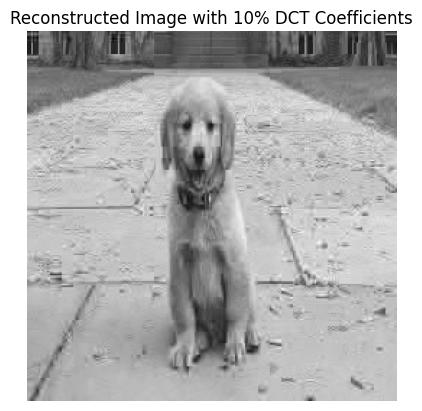

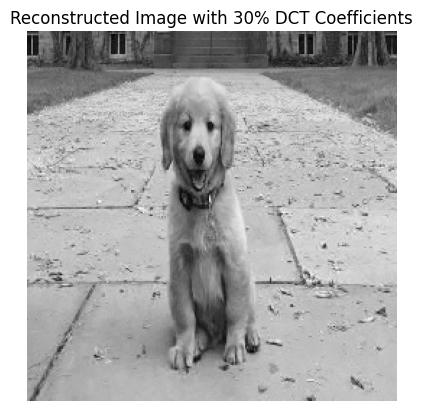

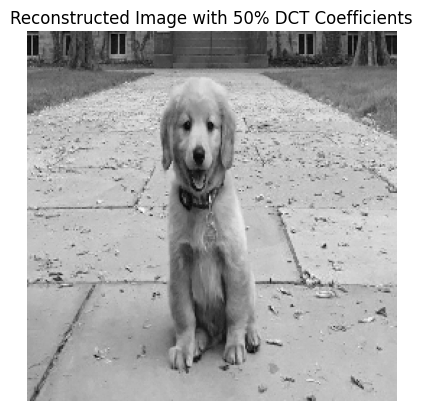

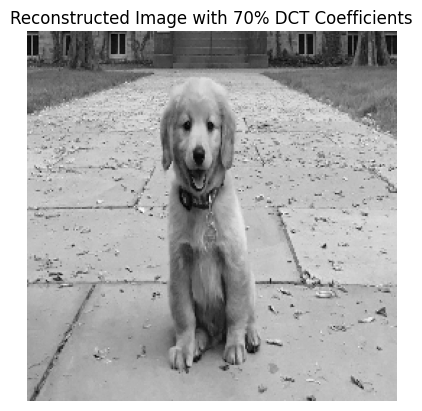

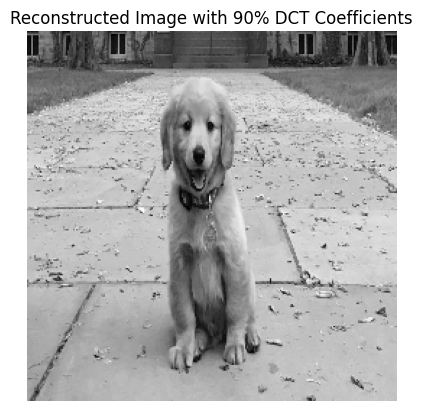

In [31]:
#now we try different compression ratios by zeroing small coefficients
def compress_dct_blocks(dct_blocks, keep_fraction):
    flattened = dct_blocks.reshape(dct_blocks.shape[0], -1)
    magnitudes = np.abs(flattened)
    compressed_blocks = np.zeros_like(flattened)
    for i in range(magnitudes.shape[0]):
        thresh = np.percentile(magnitudes[i], (1 - keep_fraction) * 100)
        compressed_blocks[i] = np.where(magnitudes[i] >= thresh, flattened[i], 0)
    return compressed_blocks.reshape(dct_blocks.shape)
compression_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
compressed_dct_blocks_list = []
for ratio in compression_ratios:
    compressed_blocks = compress_dct_blocks(dct_blocks, ratio)
    compressed_dct_blocks_list.append(compressed_blocks)
compressed_dct_blocks_list
#reconstruct images from compressed dct blocks
def reconstruct_image_from_dct_blocks(dct_blocks, image_shape, blksize):
    reconstructed_image = np.zeros(image_shape)
    idx = 0
    for i in range(0, image_shape[0], blksize):
        for j in range(0, image_shape[1], blksize):
            block_dct = dct_blocks[idx]
            block_idct_rows = idct(block_dct, axis=0, norm='ortho')
            block_idct = idct(block_idct_rows, axis=1, norm='ortho')
            reconstructed_image[i:i+blksize, j:j+blksize] = block_idct
            idx += 1
    return reconstructed_image
reconstructed_images = []
for compressed_blocks in compressed_dct_blocks_list:
    reconstructed_image = reconstruct_image_from_dct_blocks(compressed_blocks, image_resized.shape, blksize)
    reconstructed_images.append(reconstructed_image)
#display reconstructed images
for i, ratio in enumerate(compression_ratios):
    plt.imshow(reconstructed_images[i], cmap='gray')
    plt.title(f'Reconstructed Image with {int(ratio*100)}% DCT Coefficients')
    plt.axis('off')
    plt.show()
    #save the images
    cv2.imwrite(f'dct_complete_blk{blksize}_ratio{int(ratio*100)}.png', (reconstructed_images[i] * 255).astype(np.uint8))
    

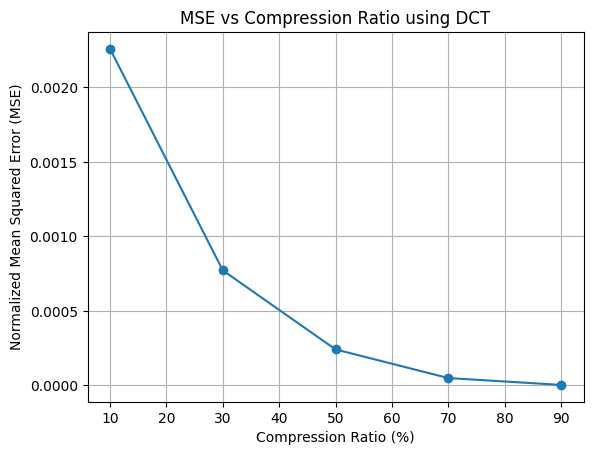

In [32]:
#now i'll calc mean squared error for each reconstructed image
#first normal image mse
mse_values = []
norm_image = np.linalg.norm(image_resized)
for reconstructed_image in reconstructed_images:
    # mse = np.mean((image_resized - reconstructed_image) ** 2) / (norm_image ** 2)
    mse = np.mean((image_resized - reconstructed_image) ** 2) 
    mse_values.append(mse)
mse_values
#plot mse vs compression ratio
plt.plot([int(r*100) for r in compression_ratios], mse_values, marker
='o')
plt.title('MSE vs Compression Ratio using DCT')
plt.xlabel('Compression Ratio (%)')
plt.ylabel('Normalized Mean Squared Error (MSE)')
plt.grid()
plt.show()



### The previous part was implemneted on 8x8 blocks, let's try 4x4 blocks now:

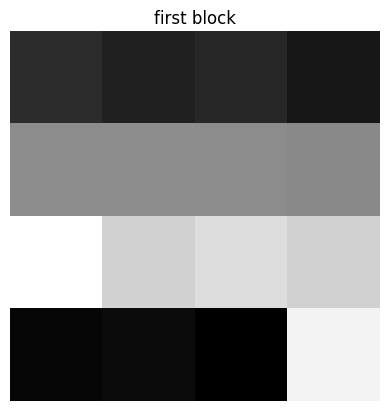

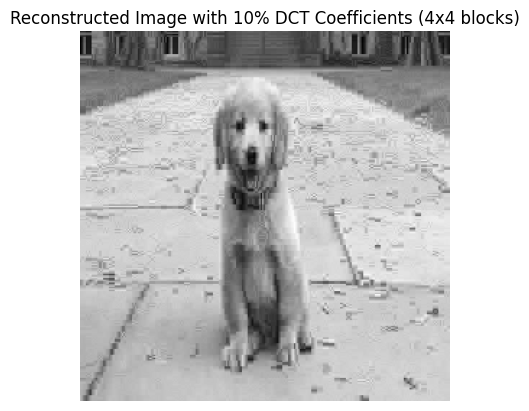

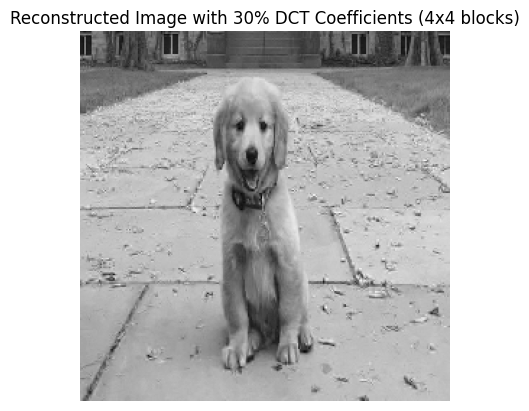

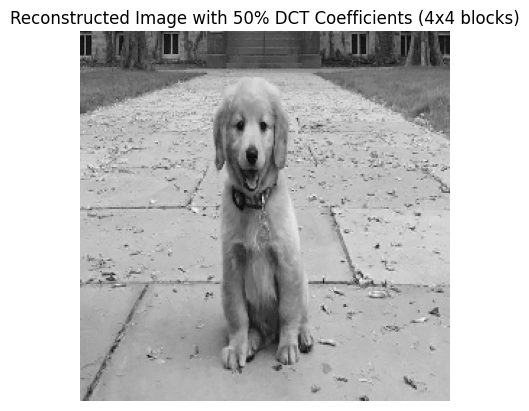

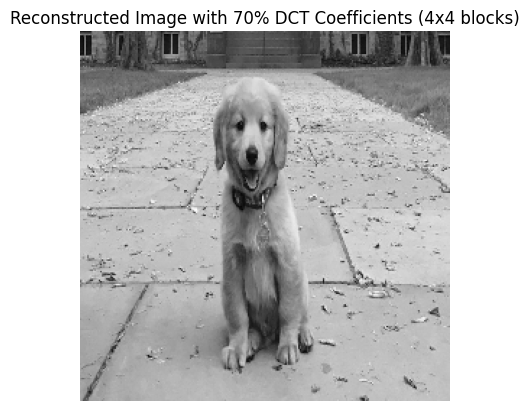

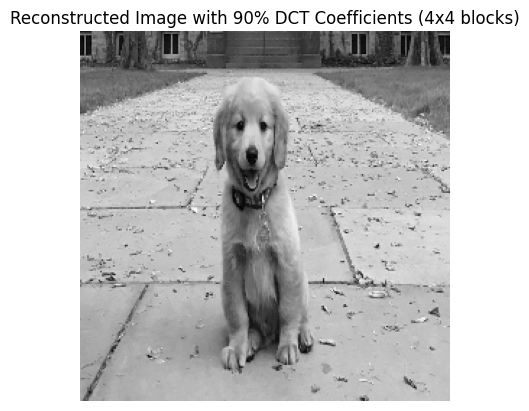

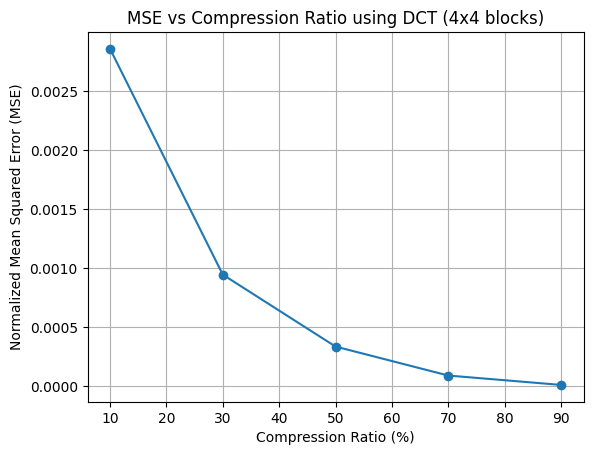

In [33]:
#divide into 4x4 blocks
blksize =4
blocks = []
for i in range(0, image_resized.shape[0], blksize):
    for j in range(0, image_resized.shape[1], blksize):
        block = image_resized[i:i+blksize, j:j+blksize]
        blocks.append(block)
blocks = np.array(blocks)
plt.imshow(blocks[0], cmap='gray')
plt.title('first block')
plt.axis('off')
plt.show()
#then repeat the same steps as before with 4x4 blocks
dct_rows = np.zeros_like(blocks)
dct_blocks = np.zeros_like(blocks)
for r in range (blocks.shape[0]):
    dct_rows[r] = dct(blocks[r], axis=1, norm='ortho')
for c in range (blocks.shape[0]):
    dct_blocks[c]=dct(dct_rows[c], axis=0, norm='ortho')
dct_blocks
#flatten first the blocks
flattened_dct_blocks = dct_blocks.reshape(dct_blocks.shape[0], -1
)
flattened_dct_blocks
#magnitudes calculation
magnitudes = np.abs(flattened_dct_blocks)
magnitudes
#now we try different compression ratios by zeroing small coefficients
def compress_dct_blocks(dct_blocks, keep_fraction):
    flattened = dct_blocks.reshape(dct_blocks.shape[0], -1)
    magnitudes = np.abs(flattened)
    compressed_blocks = np.zeros_like(flattened)
    for i in range(magnitudes.shape[0]):
        thresh = np.percentile(magnitudes[i], (1 - keep_fraction) * 100)
        compressed_blocks[i] = np.where(magnitudes[i] >= thresh, flattened[i], 0)
    return compressed_blocks.reshape(dct_blocks.shape)
compression_ratios = [0.1, 0.3, 0.5,
                        0.7, 0.9]
compressed_dct_blocks_list = []
for ratio in compression_ratios:
    compressed_blocks = compress_dct_blocks(dct_blocks, ratio)
    compressed_dct_blocks_list.append(compressed_blocks)
compressed_dct_blocks_list
#reconstruct images from compressed dct blocks
def reconstruct_image_from_dct_blocks(dct_blocks, image_shape, blksize):
    reconstructed_image = np.zeros(image_shape)
    idx = 0
    for i in range(0, image_shape[0], blksize):
        for j in range(0, image_shape[1], blksize):
            block_dct = dct_blocks[idx]
            block_idct_rows = idct(block_dct, axis=0, norm='ortho')
            block_idct = idct(block_idct_rows, axis=1, norm='ortho')
            reconstructed_image[i:i+blksize, j:j+blksize] = block_idct
            idx += 1
    return reconstructed_image
reconstructed_images = []
for compressed_blocks in compressed_dct_blocks_list:
    reconstructed_image = reconstruct_image_from_dct_blocks(compressed_blocks, image_resized.shape, blksize)
    reconstructed_images.append(reconstructed_image)
#display reconstructed images
for i, ratio in enumerate(compression_ratios):
    plt.imshow(reconstructed_images[i], cmap='gray')
    plt.title(f'Reconstructed Image with {int(ratio*100)}% DCT Coefficients (4x4 blocks)')
    plt.axis('off')
    plt.show()
    #save the images
    cv2.imwrite(f'dct_complete_blk{blksize}_ratio{int(ratio*100)}.png', (reconstructed_images[i] * 255).astype(np.uint8))
    
#now i'll calc mean squared error for each reconstructed image
#mse for 4x4 blocks
mse_values = []
norm_image = np.linalg.norm(image_resized)
for reconstructed_image in reconstructed_images:
    # mse = np.mean((image_resized - reconstructed_image) ** 2) / (norm_image ** 2)
    mse = np.mean((image_resized - reconstructed_image) ** 2) 
    mse_values.append(mse)
mse_values
#plot mse vs compression ratio
plt.plot([int(r*100) for r in compression_ratios], mse_values, marker
='o')
plt.title('MSE vs Compression Ratio using DCT (4x4 blocks)')
plt.xlabel('Compression Ratio (%)')
plt.ylabel('Normalized Mean Squared Error (MSE)')
plt.grid()
plt.show()


### Now DCT on 16x16 blocks:

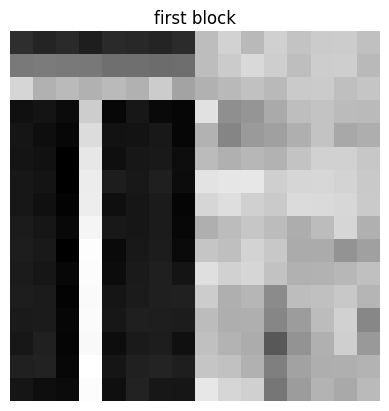

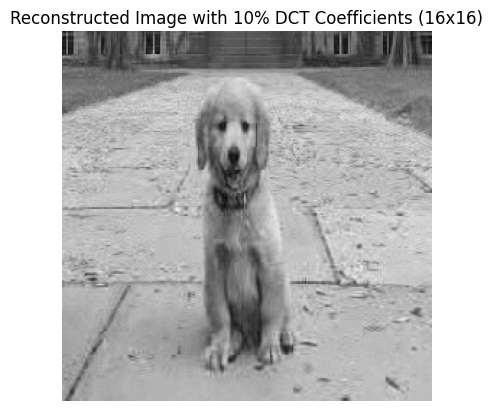

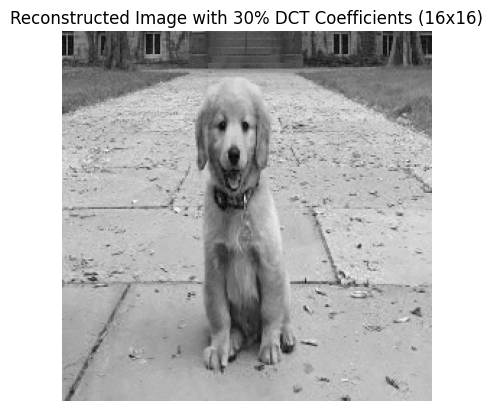

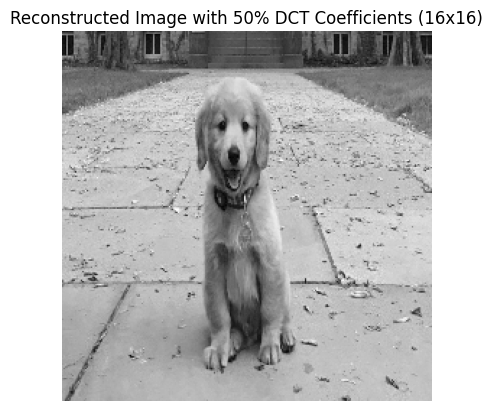

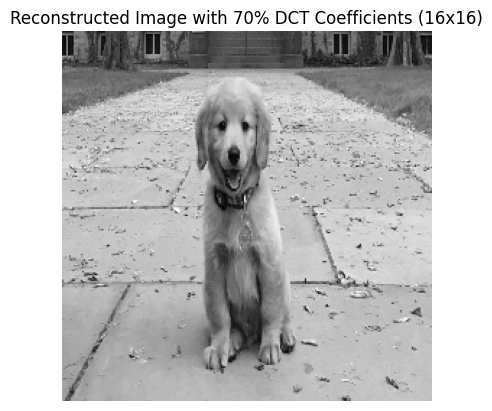

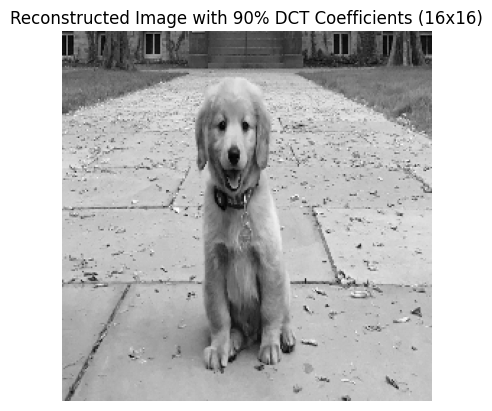

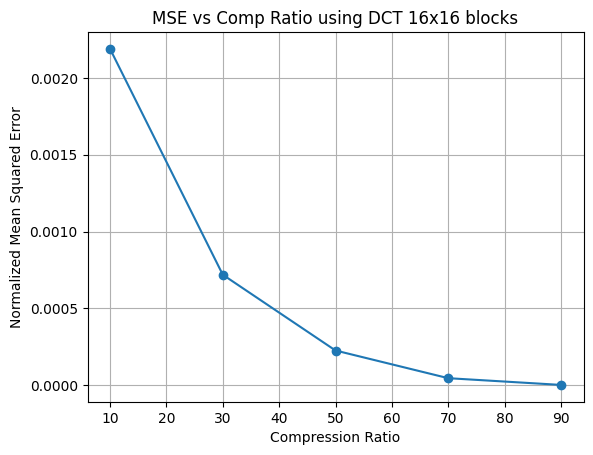

In [34]:
#divide into 16x16 blocks
blksize =16
blocks = []
for i in range(0, image_resized.shape[0], blksize):
    for j in range(0, image_resized.shape[1], blksize):
        block = image_resized[i:i+blksize, j:j+blksize]
        blocks.append(block)
blocks = np.array(blocks)
plt.imshow(blocks[0], cmap='gray')
plt.title('first block')
plt.axis('off')
plt.show()
#then repeat the same steps as before with 4x4 blocks
dct_rows = np.zeros_like(blocks)
dct_blocks = np.zeros_like(blocks)
for r in range (blocks.shape[0]):
    dct_rows[r] = dct(blocks[r], axis=1, norm='ortho')
for c in range (blocks.shape[0]):
    dct_blocks[c]=dct(dct_rows[c], axis=0, norm='ortho')
dct_blocks
#flatten first the blocks
flattened_dct_blocks = dct_blocks.reshape(dct_blocks.shape[0], -1
)
flattened_dct_blocks
#magnitudes calculation
magnitudes = np.abs(flattened_dct_blocks)
magnitudes
#now we try different compression ratios by zeroing small coefficients
def compress_dct_blocks(dct_blocks, keep_fraction):
    flattened = dct_blocks.reshape(dct_blocks.shape[0], -1)
    magnitudes = np.abs(flattened)
    compressed_blocks = np.zeros_like(flattened)
    for i in range(magnitudes.shape[0]):
        thresh = np.percentile(magnitudes[i], (1 - keep_fraction) * 100)
        compressed_blocks[i] = np.where(magnitudes[i] >= thresh, flattened[i], 0)
    return compressed_blocks.reshape(dct_blocks.shape)
compression_ratios = [0.1, 0.3, 0.5,
                        0.7, 0.9]
compressed_dct_blocks_list = []
for ratio in compression_ratios:
    compressed_blocks = compress_dct_blocks(dct_blocks, ratio)
    compressed_dct_blocks_list.append(compressed_blocks)
compressed_dct_blocks_list
#reconstruct images from compressed dct blocks
def reconstruct_image_from_dct_blocks(dct_blocks, image_shape, blksize):
    reconstructed_image = np.zeros(image_shape)
    idx = 0
    for i in range(0, image_shape[0], blksize):
        for j in range(0, image_shape[1], blksize):
            block_dct = dct_blocks[idx]
            block_idct_rows = idct(block_dct, axis=0, norm='ortho')
            block_idct = idct(block_idct_rows, axis=1, norm='ortho')
            reconstructed_image[i:i+blksize, j:j+blksize] = block_idct
            idx += 1
    return reconstructed_image
reconstructed_images = []
for compressed_blocks in compressed_dct_blocks_list:
    reconstructed_image = reconstruct_image_from_dct_blocks(compressed_blocks, image_resized.shape, blksize)
    reconstructed_images.append(reconstructed_image)
#display reconstructed images
for i, ratio in enumerate(compression_ratios):
    plt.imshow(reconstructed_images[i], cmap='gray')
    plt.title(f'Reconstructed Image with {int(ratio*100)}% DCT Coefficients (16x16)')
    plt.axis('off')
    plt.show()
    #save the images
    cv2.imwrite(f'dct_complete_blk{blksize}_ratio{int(ratio*100)}.png', (reconstructed_images[i] * 255).astype(np.uint8))
#now i'll calc mean squared error for each reconstructed image
#mse for 4x4 blocks
mse_values = []
norm_image = np.linalg.norm(image_resized)
for reconstructed_image in reconstructed_images:
    # mse = np.mean((image_resized - reconstructed_image) ** 2) / (norm_image ** 2)
    mse = np.mean((image_resized - reconstructed_image) ** 2) 
    mse_values.append(mse)
mse_values
#plot mse vs compression ratio
plt.plot([int(r*100) for r in compression_ratios], mse_values, marker
='o')
plt.title('MSE vs Comp Ratio using DCT 16x16 blocks')
plt.xlabel('Compression Ratio')
plt.ylabel('Normalized Mean Squared Error')
plt.grid()
plt.show()


### Now we compare the DCT result of 8x8, 4x4, and 16x16 blocks, and see which block size gives better compression results
### After this we'll also compare the mse vs compression ratio for DCT and how different rates affect the quality of the reconstructed image.

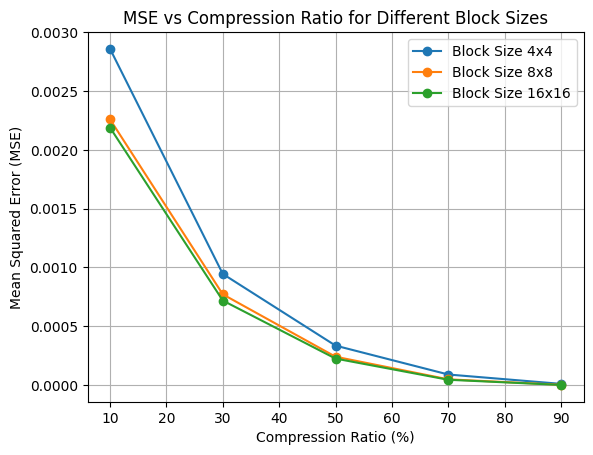

In [35]:
#comparision of results between 4x4, 8x8, and 16x16 blocks in terms of mse vs compression ratio
#plot mse vs compression ratio for all three block sizes
block_sizes = [4, 8, 16]
mse_data = {}
for blksize in block_sizes:
    # Repeat the DCT compression and MSE calculation steps for each block size
    blocks = []
    for i in range(0, image_resized.shape[0], blksize):
        for j in range(0, image_resized.shape[1], blksize):
            block = image_resized[i:i+blksize, j:j+blksize]
            blocks.append(block)
    blocks = np.array(blocks)

    dct_rows = np.zeros_like(blocks)
    dct_blocks = np.zeros_like(blocks)
    for r in range (blocks.shape[0]):
        dct_rows[r] = dct(blocks[r], axis=1, norm='ortho')
    for c in range (blocks.shape[0]):
        dct_blocks[c]=dct(dct_rows[c], axis=0, norm='ortho')

    compression_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
    compressed_dct_blocks_list = []
    for ratio in compression_ratios:
        compressed_blocks = compress_dct_blocks(dct_blocks, ratio)
        compressed_dct_blocks_list.append(compressed_blocks)

    reconstructed_images = []
    for compressed_blocks in compressed_dct_blocks_list:
        reconstructed_image = reconstruct_image_from_dct_blocks(compressed_blocks, image_resized.shape, blksize)
        reconstructed_images.append(reconstructed_image)

    mse_values = []
    norm_image = np.linalg.norm(image_resized)
    for reconstructed_image in reconstructed_images:
        mse = np.mean((image_resized - reconstructed_image) ** 2) 
        mse_values.append(mse)
    
    mse_data[blksize] = mse_values
# Plotting
plt.figure()
for blksize, mse_values in mse_data.items():
    plt.plot([int(r*100) for r in compression_ratios], mse_values, marker='o', label=f'Block Size {blksize}x{blksize}')
plt.title('MSE vs Compression Ratio for Different Block Sizes')
plt.xlabel('Compression Ratio (%)')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid()
plt.show()


We can see that 16x16 blocks give better results in terms of MSE vs Compression ratio, as larger blocks allow for more efficient representation of low frequency components, leading to better energy compaction and lower mean square error at similar compression ratios. However, larger blocks may also introduce more noticeable blocking artifacts in the reconstructed image, especially at higher compression ratios. Noticably, there is a trade off between block size, compression efficiency, and visual quality that needs to be considered based on the specific application requirements.

# NEXT, We Implement DFT and compare results with DCT

In [36]:
%pip install tabulate


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


MSE: 0.005349
MSE: 0.001803
MSE: 0.000698
MSE: 0.000259
MSE: 0.000051
MSE: 0.003344
MSE: 0.001335
MSE: 0.000562
MSE: 0.000199
MSE: 0.000025
MSE: 0.003003
MSE: 0.001221
MSE: 0.000500
MSE: 0.000158
MSE: 0.000017

 MSE RESULTS: 
+-------------------+-------------+-------------+---------------+
|  Retention Ratio  |   Block 4×4 |   Block 8×8 |   Block 16×16 |
+===================+=============+=============+===============+
|        10%        |    0.005349 |    0.003344 |      0.003003 |
+-------------------+-------------+-------------+---------------+
|        30%        |    0.001803 |    0.001335 |      0.001221 |
+-------------------+-------------+-------------+---------------+
|        50%        |    0.000698 |    0.000562 |      0.0005   |
+-------------------+-------------+-------------+---------------+
|        70%        |    0.000259 |    0.000199 |      0.000158 |
+-------------------+-------------+-------------+---------------+
|        90%        |    5.1e-05  |    2.5e-05  

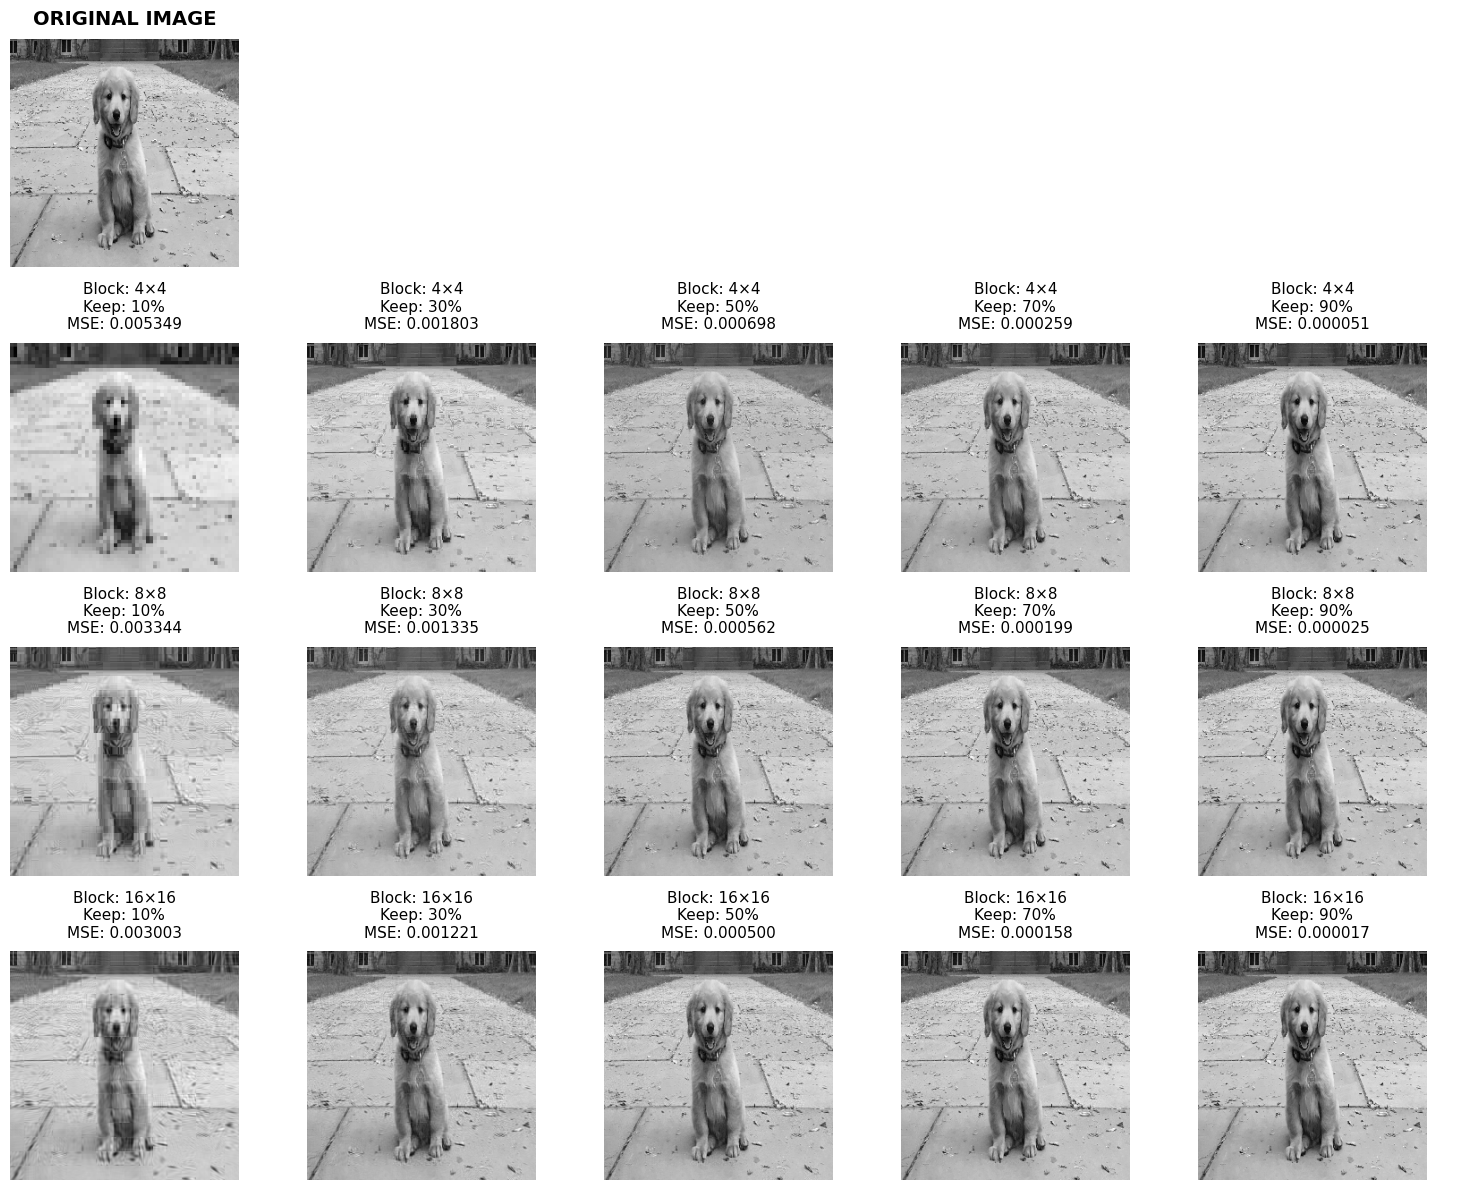

Comparison grid saved as: COMPARISON_GRID.png


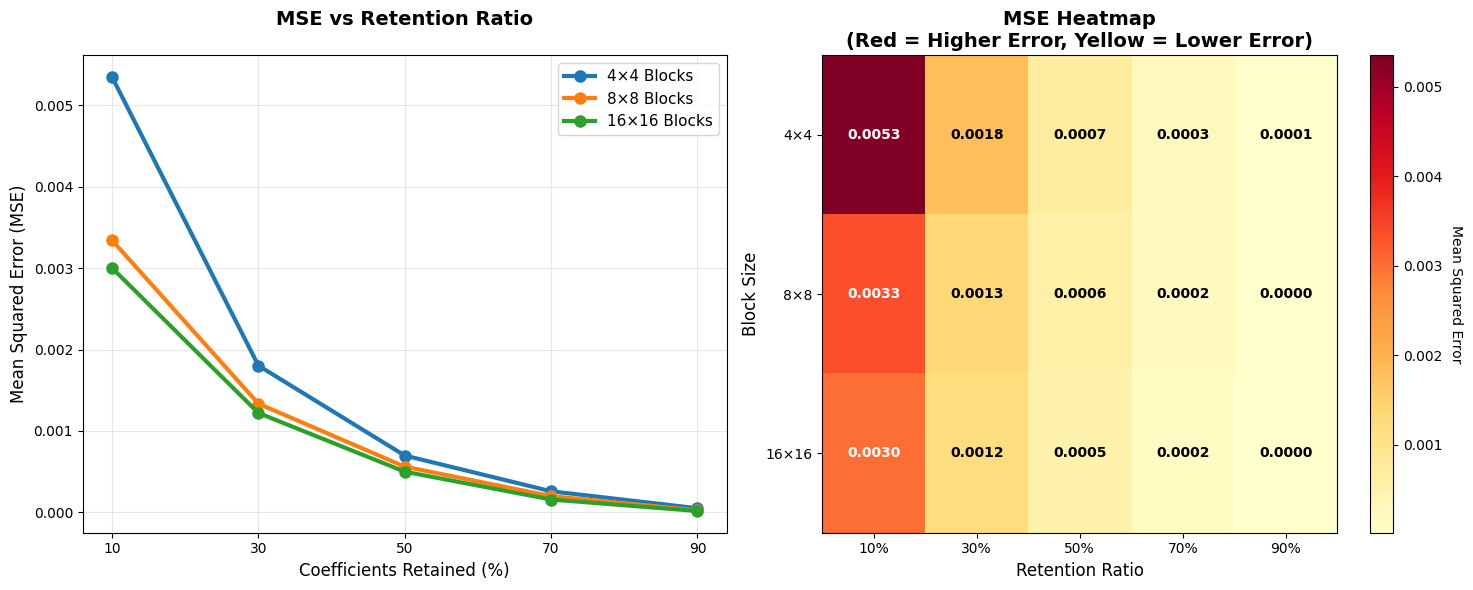

MSE analysis saved as: MSE_ANALYSIS.png


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft
import pandas as pd
from tabulate import tabulate

# 2D DFT functions using 1D FFT twice
def fft2d(block):
    return fft(fft(block, axis=0), axis=1)

def ifft2d(block):
    return ifft(ifft(block, axis=0), axis=1)

# this function connects to the energy compaction property of the fourier transform where most visual information is in low frequency components so we keep the coefficients with the highest magnitudes

def keep_largest_coefficients(block, retention_ratio=0.25): # Retain only the largest coefficients, the retention_ratio is the fraction to keep
    flat_block = block.flatten()
    magnitudes = np.abs(flat_block) # higher energy frequencies contribute more to the image 
    
    num_coeffs = len(flat_block)
    num_keep = max(1, int(num_coeffs * retention_ratio)) # Ensure at least one coefficient is kept
    largest_indices = np.argpartition(magnitudes, -num_keep)[-num_keep:] # this step partially sorts the array and returns indices of the largest num_keep elements, which is more efficient than a full sort
    new_flat = np.zeros_like(flat_block, dtype=complex) # zeros out all frequencies then only copies the largest magnitude coefficients
    new_flat[largest_indices] = flat_block[largest_indices]
    return new_flat.reshape(block.shape) #goes back to 2D

#this function applies zero padding because fft expect input of a specific size

def process_image_with_fft(image, blksize=8, retention_ratio=0.25):
    
    if image.dtype != np.float64:
        image = image.astype(np.float64) #FFT works best with floating-point numbers 
    height, width = image.shape

    blocks = []
    block_positions = []
    block_was_padded = []  # flags which block needed padding to not lose information on the edges
    
    for i in range(0, height, blksize):
        for j in range(0, width, blksize): 
            end_i = min(i + blksize, height) # to handle edges cases where block exceeds image dimensions
            end_j = min(j + blksize, width)
            block = image[i:end_i, j:end_j]
            if block.shape != (blksize, blksize): # if block is smaller than blksize, we pad it with zeros
                padded_block = np.zeros((blksize, blksize), dtype=image.dtype) # to create a blank block of the target size 
                padded_block[:block.shape[0], :block.shape[1]] = block # copies the original data into the top left corner 
                blocks.append(padded_block)
                block_was_padded.append(True)
            else:
                blocks.append(block)
                block_was_padded.append(False)
            
            block_positions.append((i, j))
    reconstructed_blocks = []
    
    for block_idx, block in enumerate(blocks): #enumarate to keep track of which block we're processing
        fft_block = fft2d(block) # the result is a matrix of complex numbers
        filtered_block = keep_largest_coefficients(fft_block, retention_ratio) #compression step
        reconstructed_block = ifft2d(filtered_block).real #converts the filtered coefficients back to spatial domain and takes the real part
        reconstructed_blocks.append(reconstructed_block)
    
    reconstructed_image = np.zeros_like(image, dtype=np.float64) # creates an empty image with the same dimensions as the original
    
    for idx, (i, j) in enumerate(block_positions): # basically to place block idx back to position (i,j) in the output image 
        reconstructed_block = reconstructed_blocks[idx]
        was_padded = block_was_padded[idx] # to avoid copying unecessary padded zeros back into the image
        original_height = min(blksize, height - i)
        original_width = min(blksize, width - j) # this is done to compute how many valid rows and columns the original block had (thinking in terms of indices)

        if was_padded:
            reconstructed_image[i:i+original_height, j:j+original_width] = \
                reconstructed_block[:original_height, :original_width] # if block was padded, only copy the real part 
        else:
            reconstructed_image[i:i+blksize, j:j+blksize] = reconstructed_block
    
    return reconstructed_image

def compute_mse(original, reconstructed):
    # make sure both images are the same size 
    min_height = min(original.shape[0], reconstructed.shape[0])
    min_width = min(original.shape[1], reconstructed.shape[1])
    #this is to remove any padded regions and ensure both images are the same size for comparison 
    original_crop = original[:min_height, :min_width]
    reconstructed_crop = reconstructed[:min_height, :min_width]
    mse = np.mean((original_crop - reconstructed_crop) ** 2) # subtracts the reconstructed image from the original, squares the differences, and averages them
    return mse

def run_all_experiments(image, block_sizes=[4, 8, 16], retention_ratios=[0.1, 0.3, 0.5, 0.7, 0.9]):
    image_normalized = (image - image.min()) / (image.max() - image.min())
    height, width = image_normalized.shape
    results = {}
    
    for blksize in block_sizes:
        blocks_vertical = (height + blksize - 1) // blksize # calculates how many vertical blocks we need to cover the whole image (H+B-1/B, if H is a multiple of B this gives H/B, else it rounds up to cover the remainder)
        blocks_horizontal = (width + blksize - 1) // blksize
        for ratio in retention_ratios:
            
            try:
                reconstructed = process_image_with_fft(
                    image_normalized, blksize=blksize, retention_ratio=ratio
                )
                mse = compute_mse(image_normalized, reconstructed)
                print(f"MSE: {mse:.6f}")
                key = f"blk{blksize}_ratio{ratio}"
                results[key] = {
                    'reconstructed': reconstructed,
                    'mse': mse,
                    'block_size': blksize,
                    'retention_ratio': ratio
                }
                reconstructed_denorm = (reconstructed * 255).astype(np.uint8) #denormalize to [0,255] for saving
                filename = f'dft_complete_blk{blksize}_ratio{int(ratio*100)}.png'
                plt.imsave(filename, reconstructed_denorm, cmap='gray')
                
            except Exception as e:
                print(f"ERROR: {e}")
                key = f"blk{blksize}_ratio{ratio}"
                results[key] = {
                    'reconstructed': None,
                    'mse': float('nan'),
                    'block_size': blksize,
                    'retention_ratio': ratio
                }
    
    return results, image_normalized

def display_comprehensive_results(results):
    block_sizes = [4, 8, 16]
    retention_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
    table_data = [] #initializes an empty list to hold the rows of the table
    for ratio in retention_ratios:
        row = [f"{ratio*100:.0f}%"]
        for blksize in block_sizes:
            key = f"blk{blksize}_ratio{ratio}"
            if key in results and not np.isnan(results[key]['mse']): # makes sure MSE is valid
                mse = results[key]['mse']
                status = " "
                display_text = f"{mse:.6f} {status}"
            else:
                display_text = "FAILED"
            row.append(display_text)
        table_data.append(row)
    
    headers = ["Retention Ratio"] + [f"Block {bs}×{bs}" for bs in block_sizes]
    
    print("\n MSE RESULTS: ")
    print(tabulate(table_data, headers=headers, tablefmt="grid", stralign="center")) # tabulate library was used to print the table in grid format
    
#just to create of comparison grid of the different cases 
def create_comparison_grid(original, results, filename='COMPARISON_GRID.png'):
    block_sizes = [4, 8, 16]
    retention_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
    # rows = one row for the original + one row per block size
    num_rows = len(block_sizes) + 1
    num_cols = len(retention_ratios)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(3 * num_cols, 3 * num_rows))
    # ensure axes is 2D array (in case num_rows or num_cols == 1)
    axes = np.atleast_2d(axes)
    # place original in the top-left cell and turn off other top-row cells
    axes[0, 0].imshow(original, cmap='gray')
    axes[0, 0].set_title('ORIGINAL IMAGE', fontsize=14, fontweight='bold', pad=10)
    axes[0, 0].axis('off')
    for c in range(1, num_cols):
        axes[0, c].axis('off')
    for row_idx, blksize in enumerate(block_sizes): #loops over block sizes and retention ratios to fill the grid
        for col_idx, ratio in enumerate(retention_ratios):
            key = f"blk{blksize}_ratio{ratio}"
            
            ax = axes[row_idx+1, col_idx]
            if key in results and results[key]['reconstructed'] is not None:
                recon = results[key]['reconstructed']
                mse = results[key]['mse']
                ax.imshow(recon, cmap='gray')
                ax.set_title(
                    f'Block: {blksize}×{blksize}\nKeep: {ratio*100:.0f}%\nMSE: {mse:.6f}', 
                    fontsize=11, 
                    pad=10
                )
                ax.axis('off')
            else:
                ax.text(0.5, 0.5, 'FAILED', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=12, color='red', fontweight='bold')
                ax.set_title(
                    f'Block: {blksize}×{blksize}\nKeep: {ratio*100:.0f}%\nMSE: N/A', 
                    fontsize=11, 
                    pad=10
                )
                ax.axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Comparison grid saved as: {filename}")

def plot_mse_analysis(results, filename='MSE_ANALYSIS.png'):
    block_sizes = [4, 8, 16]
    retention_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    for blksize in block_sizes:
        mse_values = []
        ratios_display = []
        
        for ratio in retention_ratios:
            key = f"blk{blksize}_ratio{ratio}"
            if key in results and not np.isnan(results[key]['mse']):
                mse_values.append(results[key]['mse'])
                ratios_display.append(ratio * 100)
        if mse_values:
            ax1.plot(ratios_display, mse_values, 'o-', linewidth=3, markersize=8, 
                    label=f'{blksize}×{blksize} Blocks')
    
    ax1.set_xlabel('Coefficients Retained (%)', fontsize=12)
    ax1.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
    ax1.set_title('MSE vs Retention Ratio\n', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks([ratio * 100 for ratio in retention_ratios])
    mse_matrix = np.zeros((len(block_sizes), len(retention_ratios)))
    #mse matrix for heatmap
    for i, blksize in enumerate(block_sizes):
        for j, ratio in enumerate(retention_ratios):
            key = f"blk{blksize}_ratio{ratio}"
            if key in results and not np.isnan(results[key]['mse']):
                mse_matrix[i, j] = results[key]['mse']
            else:
                mse_matrix[i, j] = np.nan
    im = ax2.imshow(mse_matrix, cmap='YlOrRd', aspect='auto')  #red for high mse while yellow for low
    # adds the numeric value of mse inside each cell
    for i in range(len(block_sizes)):
        for j in range(len(retention_ratios)):
            if not np.isnan(mse_matrix[i, j]):
                cell_value = mse_matrix[i, j]
                text_color = 'white' if cell_value > np.nanmax(mse_matrix) * 0.5 else 'black'
                ax2.text(j, i, f'{mse_matrix[i, j]:.4f}', 
                        ha='center', va='center', fontweight='bold', 
                        fontsize=10, color=text_color) 
    
    ax2.set_xticks(range(len(retention_ratios)))
    ax2.set_yticks(range(len(block_sizes)))
    ax2.set_xticklabels([f'{r*100:.0f}%' for r in retention_ratios])
    ax2.set_yticklabels([f'{bs}×{bs}' for bs in block_sizes])
    ax2.set_xlabel('Retention Ratio', fontsize=12)
    ax2.set_ylabel('Block Size', fontsize=12)
    ax2.set_title('MSE Heatmap\n(Red = Higher Error, Yellow = Lower Error)', fontsize=14, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax2, label='MSE')
    cbar.set_label('Mean Squared Error', rotation=270, labelpad=15)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"MSE analysis saved as: {filename}")

def save_detailed_results_csv(results, filename='RESULTS.csv'):
    data_rows = []
    for key, result in results.items():
        if result['reconstructed'] is not None and not np.isnan(result['mse']):
            data_rows.append({
                'Block_Size': result['block_size'],
                'Retention_Ratio_Percent': result['retention_ratio'] * 100,
                'Retention_Ratio': result['retention_ratio'],
                'MSE': result['mse'],
                'Status': 'SUCCESS'
            })
        else:
            data_rows.append({
                'Block_Size': result['block_size'],
                'Retention_Ratio_Percent': result['retention_ratio'] * 100,
                'Retention_Ratio': result['retention_ratio'],
                'MSE': 'FAILED',
                'Status': 'FAILED'
            })
    
    df = pd.DataFrame(data_rows) #creates a dataframe then sorts it 
    df = df.sort_values(['Block_Size', 'Retention_Ratio_Percent'])
    df.to_csv(filename, index=False)
    print(f"Detailed results saved as: {filename}")

# MAIN EXECUTION
if __name__ == "__main__":
    if 'image_resized' not in globals():
        print("Creating test image since image_resized not found")
        image_resized = create_synthetic_image((256, 256))
    
    # Run experiments
    all_results, normalized_original = run_all_experiments(image_resized)
    
    # Display results
    display_comprehensive_results(all_results)
    
    # Create visualizations
    create_comparison_grid(normalized_original, all_results)
    plot_mse_analysis(all_results)

    


### Comparison of DCT and DFT for image compression:

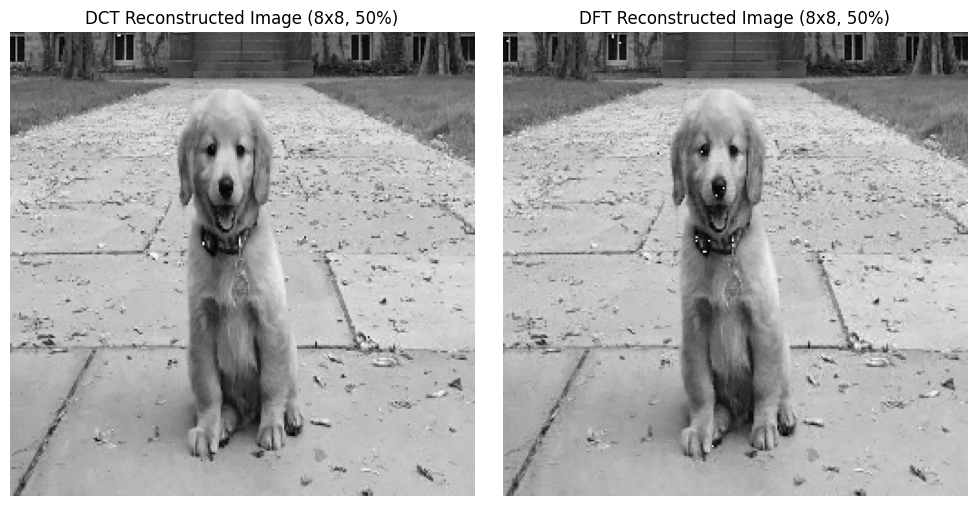

MSE DCT (8x8, 50%): 0.000332
MSE DFT (8x8, 50%): 0.000785


In [50]:
# Comparison of DCT and DFT results for 8x8 blocks and 50% retention using the previously saved images
dct_image_raw = plt.imread('dct_complete_blk8_ratio50.png')
dft_image_raw = plt.imread('dft_complete_blk8_ratio50.png')

# convert to grayscale if loaded images have color / alpha channels
def to_gray_if_needed(img):
    if img.ndim == 3:
        # drop alpha channel if present
        if img.shape[2] == 4:
            img = img[..., :3]
        return rgb2gray(img)
    return img

dct_image = to_gray_if_needed(dct_image_raw)
dft_image = to_gray_if_needed(dft_image_raw)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(dct_image, cmap='gray', vmin=0, vmax=1)
plt.title('DCT Reconstructed Image (8x8, 50%)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(dft_image, cmap='gray', vmin=0, vmax=1)
plt.title('DFT Reconstructed Image (8x8, 50%)')
plt.axis('off')
plt.tight_layout()
plt.show()

# now i'll calc mse for both images
def calculate_mse(image1, image2):
    min_height = min(image1.shape[0], image2.shape[0])
    min_width = min(image1.shape[1], image2.shape[1])
    image1_crop = image1[:min_height, :min_width]
    image2_crop = image2[:min_height, :min_width]
    mse = np.mean((image1_crop - image2_crop) ** 2)
    return mse

mse_dct = calculate_mse(image_resized, dct_image)
mse_dft = calculate_mse(image_resized, dft_image)
print(f"MSE DCT (8x8, 50%): {mse_dct:.6f}")
print(f"MSE DFT (8x8, 50%): {mse_dft:.6f}")


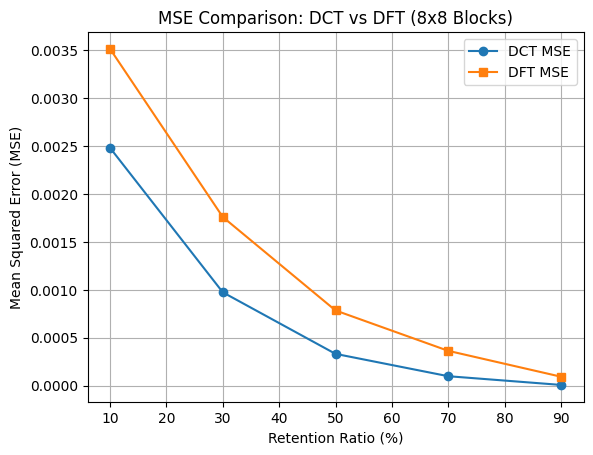

In [51]:
#plot mse of dct vs dft for 8x8 blocks and different retention ratios
retention_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
mse_dct_values = []
mse_dft_values = []
for ratio in retention_ratios:
    dct_image_path = f'dct_complete_blk8_ratio{int(ratio*100)}.png'
    dft_image_path = f'dft_complete_blk8_ratio{int(ratio*100)}.png'
    dct_image = to_gray_if_needed(plt.imread(dct_image_path))
    dft_image = to_gray_if_needed(plt.imread(dft_image_path))
    mse_dct = calculate_mse(image_resized, dct_image)
    mse_dft = calculate_mse(image_resized, dft_image)
    mse_dct_values.append(mse_dct)
    mse_dft_values.append(mse_dft)
plt.plot([int(r*100) for r in retention_ratios], mse_dct_values, marker='o', label='DCT MSE')
plt.plot([int(r*100) for r in retention_ratios], mse_dft_values
, marker='s', label='DFT MSE')
plt.title('MSE Comparison: DCT vs DFT (8x8 Blocks)')
plt.xlabel('Retention Ratio (%)')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid()
plt.show()


We can notice that DCT outperforms DFT in terms of image compression quality at the same retention ratio. The DCT reconstructed image retains more visual details and has fewer artifacts compared to the DFT reconstructed image. This is because DCT is better at energy compaction, concentrating most of the signal information in a few low-frequency coefficients, which allows for more effective compression. In contrast, DFT spreads the energy more evenly across all frequencies, making it less efficient for compression tasks. As a result, when retaining only a portion of the coefficients, DCT provides a higher quality reconstruction than DFT.

# Entropy Coding: